In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cài đặt tất cả thư viện cần cho toàn bộ notebook
!pip install -q ftfy transformers datasets torch scikit-learn accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


# 🅰️ PHẦN A — Tiền xử lý dữ liệu

*Đầu vào:* `raw_data/welfake.csv` → *Đầu ra:* `cleaned_data/welfake_cleaned.csv`

## 1. Thiết lập môi trường

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import unicodedata
import ftfy

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)

# Lưu số dòng sau mỗi bước -> dùng cho báo cáo tổng kết ở Mục 7
pipeline_log = []
def log_stage(name, dataframe):
    pipeline_log.append({'Bước xử lý': name, 'Số dòng còn lại': len(dataframe)})
    print(f'[LOG] {name}: {len(dataframe):,} dòng')

## 2. Đọc dữ liệu thô và khám phá (EDA)

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DS102/raw_data/welfake.csv')
log_stage('0. Dữ liệu thô ban đầu', df)

[LOG] 0. Dữ liệu thô ban đầu: 72,134 dòng


In [ ]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terr...,No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of N...,"Now, most of the demonstrators gathered last night were exercising their constitutional and protected right to peac...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid",A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in ...,0
4,4,SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice,"The RS-28 Sarmat missile, dubbed Satan 2, will replace the SS-18 Flies at 4.3 miles (7km) per sec and with a range o...",1


In [ ]:
print("Cấu trúc bộ dữ liệu:")
print(df.shape)
print("\nKiểu dữ liệu:")
print(df.dtypes)
print("\nThông tin tổng quan:")
df.info()

Cấu trúc bộ dữ liệu:
(72134, 4)

Kiểu dữ liệu:
Unnamed: 0     int64
title         object
text          object
label          int64
dtype: object

Thông tin tổng quan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [ ]:
missing_df = df.isnull().sum().to_frame(name="Số lượng khuyết")
missing_df["Tỷ lệ khuyết (%)"] = (df.isnull().mean() * 100).round(2)
print(missing_df)

            Số lượng khuyết  Tỷ lệ khuyết (%)
Unnamed: 0                0              0.00
title                   558              0.77
text                     39              0.05
label                     0              0.00


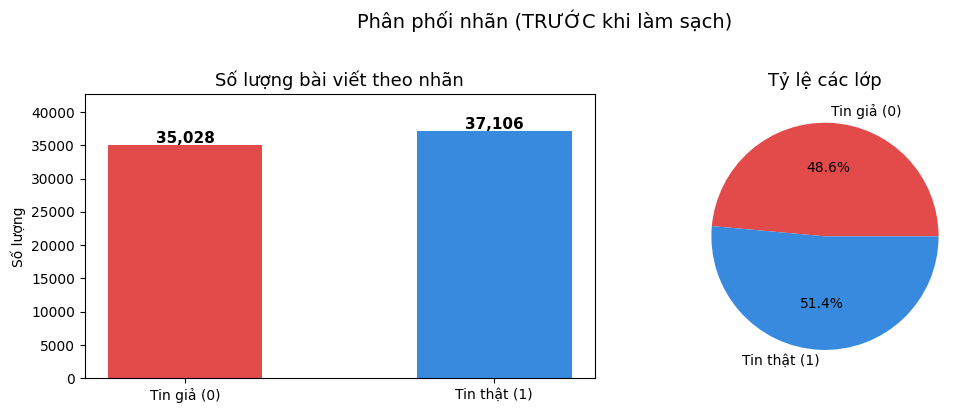

label
0    35028
1    37106

Tỷ lệ cân bằng (Thật/Giả): 1.059


In [ ]:
# Phân phối nhãn ban đầu (0 = Tin giả, 1 = Tin thật) -> lưu lại để so sánh sau khi làm sạch
initial_label_counts = df['label'].value_counts().sort_index()
labels_map = {0: "Tin giả (0)", 1: "Tin thật (1)"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar([labels_map[k] for k in initial_label_counts.index], initial_label_counts.values,
            color=["#E24B4A", "#378ADD"], width=0.5)
for i, v in enumerate(initial_label_counts.values):
    axes[0].text(i, v + 300, f"{v:,}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Số lượng bài viết theo nhãn", fontsize=13)
axes[0].set_ylabel("Số lượng")
axes[0].set_ylim(0, initial_label_counts.max() * 1.15)

axes[1].pie(initial_label_counts.values, labels=[labels_map[k] for k in initial_label_counts.index],
            colors=["#E24B4A", "#378ADD"], autopct="%1.1f%%")
axes[1].set_title("Tỷ lệ các lớp", fontsize=13)
plt.suptitle("Phân phối nhãn (TRƯỚC khi làm sạch)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(initial_label_counts.to_string())
print(f"\nTỷ lệ cân bằng (Thật/Giả): {initial_label_counts[1]/initial_label_counts[0]:.3f}")

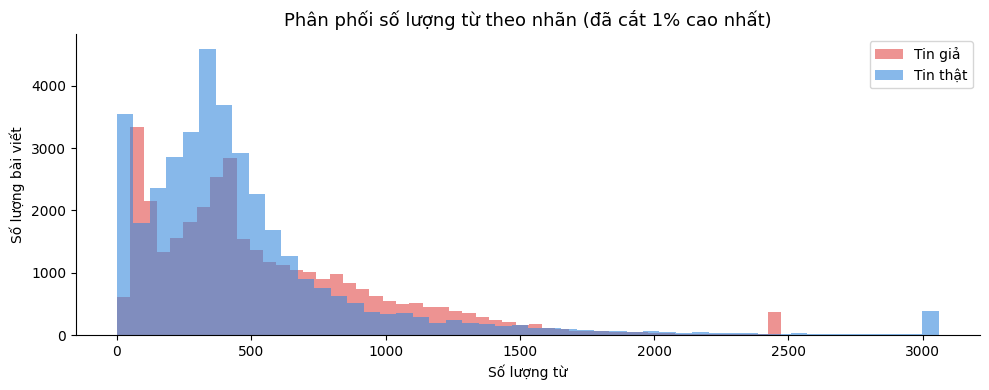

In [ ]:
# Phân phối số lượng từ theo nhãn (cắt 1% ngoại lai cao nhất để dễ quan sát)
tmp = df.copy()
tmp['text_words'] = tmp['text'].fillna("").apply(lambda x: len(x.split()))
tmp['label_name'] = tmp['label'].map({0: "Tin giả", 1: "Tin thật"})
palette = {"Tin giả": "#E24B4A", "Tin thật": "#378ADD"}

fig, ax = plt.subplots(figsize=(10, 4))
for lname, grp in tmp.groupby("label_name"):
    ax.hist(grp['text_words'].clip(upper=grp['text_words'].quantile(0.99)),
            bins=50, alpha=0.6, color=palette[lname], label=lname, edgecolor="none")
ax.set_title("Phân phối số lượng từ theo nhãn (đã cắt 1% cao nhất)", fontsize=13)
ax.set_xlabel("Số lượng từ"); ax.set_ylabel("Số lượng bài viết"); ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()
del tmp

## 3. Làm sạch cấu trúc dữ liệu

In [ ]:
# 3.1. Xóa cột chỉ số thừa
df = df.drop(columns=['Unnamed: 0'])
print("Các cột còn lại:", df.columns.tolist())

Các cột còn lại: ['title', 'text', 'label']


In [ ]:
# 3.2. Xử lý giá trị khuyết (mềm hóa)
# - Bắt buộc phải có 'text' và 'label' -> thiếu thì xóa (không có nội dung/nhãn thì không dùng được).
# - Riêng 'title' khuyết: GIỮ LẠI dòng và điền chuỗi rỗng, vì 'text' vẫn mang nội dung
#   (ta gộp title + text). Tránh vứt bỏ mẫu hợp lệ một cách lãng phí.
before = len(df)
df = df.dropna(subset=['text', 'label'], how='any')
n_title_missing = df['title'].isnull().sum()
df['title'] = df['title'].fillna('')
print(f"Đã xóa {before - len(df):,} dòng thiếu text/label.")
print(f"Giữ lại & điền rỗng cho {n_title_missing:,} dòng chỉ thiếu title.")
log_stage('1. Sau khi xử lý giá trị khuyết', df)

Đã xóa 39 dòng thiếu text/label.
Giữ lại & điền rỗng cho 558 dòng chỉ thiếu title.
[LOG] 1. Sau khi xử lý giá trị khuyết: 72,095 dòng


In [ ]:
# 3.3. Gộp title + text  &  3.4. Đổi tên nhãn
df['Text'] = df['title'].astype(str) + ' ' + df['text'].astype(str)
df = df.drop(columns=['title', 'text'])
df = df.rename(columns={'label': 'labels'})
df['labels'] = df['labels'].astype(int)
print("Các cột sau khi gộp & đổi tên:", df.columns.tolist())
df.head()

Các cột sau khi gộp & đổi tên: ['labels', 'Text']


,labels,Text
0,1,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terr...
1,1,Did they post their votes for Hillary already?
2,1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of N...
3,0,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid A dozen po..."
4,1,SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice The RS-28 Sarmat mis...


## 4. Chuẩn hóa nội dung văn bản (làm sạch nhẹ, phù hợp BERT)

Do mô hình mục tiêu là **BERT**, ta chỉ loại bỏ nhiễu thật sự và **giữ lại chữ hoa cùng dấu câu** — những tín hiệu ngữ nghĩa mà BERT khai thác (ví dụ tiêu đề VIẾT HOA hay nhiều dấu `!`, `?` thường là đặc trưng của tin giả).

| Bước | Mục đích |
|------|----------|
| `ftfy.fix_text` | Sửa lỗi mã hóa (mojibake): `\x92`, `\x93`, `\x94`... |
| `unicodedata.normalize('NFKC')` | Chuẩn hóa Unicode: nháy cong `'`/`"`, gạch dài `—`, `…` về dạng chuẩn |
| Xóa URL & email | Loại bỏ liên kết, địa chỉ email gây nhiễu |
| Xóa HTML tag & `[...]` | Loại bỏ thẻ HTML và chú thích kiểu `[VIDEO]`, `[PHOTO]` |
| Chuẩn hóa khoảng trắng | Gộp nhiều khoảng trắng thành một |

> **Giữ nguyên** chữ hoa/thường và dấu câu (KHÔNG `lower()`, KHÔNG xóa dấu câu). Đây là điểm khác biệt then chốt so với tiền xử lý dành cho mô hình truyền thống (TF-IDF).

In [ ]:
def standardize_text(text):
    """Làm sạch NHẸ cho BERT: giữ chữ hoa & dấu câu, chỉ loại bỏ nhiễu."""
    if not isinstance(text, str):
        return ''
    text = ftfy.fix_text(text)                      # 1. Sửa lỗi mã hóa
    text = unicodedata.normalize('NFKC', text)      # 2. Chuẩn hóa Unicode
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # 3. Xóa URL
    text = re.sub(r'\S+@\S+', ' ', text)            # 4. Xóa email
    text = re.sub(r'<.*?>', ' ', text)              # 5. Xóa HTML tag
    text = re.sub(r'\[[^\]]*\]', ' ', text)         # 6. Xóa [VIDEO], [PHOTO]...
    text = re.sub(r'\s+', ' ', text).strip()         # 7. Chuẩn hóa khoảng trắng
    return text

In [ ]:
# So sánh trước/sau trên một mẫu thực tế
sample_before = df['Text'].iloc[0]
sample_after = standardize_text(sample_before)
print("--- TRƯỚC ---")
print(sample_before[:300])
print("\n--- SAU (giữ chữ hoa + dấu câu) ---")
print(sample_after[:300])

--- TRƯỚC ---
LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cop

--- SAU (giữ chữ hoa + dấu câu) ---
LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They 


In [ ]:
df['Text'] = df['Text'].apply(standardize_text)
print("Đã chuẩn hóa xong cột 'Text'.")

Đã chuẩn hóa xong cột 'Text'.


## 5. Dọn dẹp sau chuẩn hóa

In [ ]:
# 5.1. PHÂN TÍCH các bài quá ngắn trước khi quyết định loại bỏ (tránh mất thông tin tùy tiện)
word_count = df['Text'].str.split().str.len()
print("Phân vị độ dài (số từ) ở vùng thấp:")
for q in [0.001, 0.005, 0.01, 0.02]:
    print(f"  {q*100:>4}%: {word_count.quantile(q):.0f} từ")

print("\nSố bài và phân phối nhãn theo từng ngưỡng ngắn:")
for thr in [1, 3, 5]:
    sub = df[word_count < thr]
    print(f"  < {thr} từ: {len(sub):,} dòng  | nhãn: {dict(sub['labels'].value_counts().sort_index())}")

print("\nVí dụ vài bài ngắn nhất:")
for t in df[word_count < 5]['Text'].head(5).tolist():
    print("   ->", repr(t))

Phân vị độ dài (số từ) ở vùng thấp:
   0.1%: 4 từ
   0.5%: 11 từ
   1.0%: 14 từ
   2.0%: 23 từ

Số bài và phân phối nhãn theo từng ngưỡng ngắn:
  < 1 từ: 9 dòng  | nhãn: {1: np.int64(9)}
  < 3 từ: 35 dòng  | nhãn: {1: np.int64(35)}
  < 5 từ: 85 dòng  | nhãn: {0: np.int64(1), 1: np.int64(84)}

Ví dụ vài bài ngắn nhất:
   -> 'Cool'
   -> 'Obamas blunder.'
   -> ''
   -> 'That would be unconstitutional.'
   -> 'Graphic: Supreme Court roundup'


In [ ]:
# 5.2. Loại bỏ bài rỗng và quá ngắn (< 5 từ): số lượng rất nhỏ, chỉ là tiêu đề rời/nhiễu,
# không đủ ngữ cảnh cho BERT.
MIN_WORDS = 5
before = len(df)
df = df[df['Text'].str.split().str.len() >= MIN_WORDS].reset_index(drop=True)
print(f"Đã xóa {before - len(df):,} dòng có < {MIN_WORDS} từ ({(before-len(df))/before*100:.3f}% dữ liệu).")
log_stage('2. Sau khi xóa dòng rỗng/quá ngắn', df)

Đã xóa 85 dòng có < 5 từ (0.118% dữ liệu).
[LOG] 2. Sau khi xóa dòng rỗng/quá ngắn: 72,010 dòng


In [ ]:
# 5.3. Khử trùng lặp GẦN ĐÚNG (near-duplicate).
# Vì ta giữ chữ hoa & dấu câu, hai bài giống hệt nhau nhưng chỉ khác hoa/thường hoặc dấu câu
# sẽ KHÔNG bị bắt bởi dedup chính xác -> đây là nguồn rò rỉ dữ liệu (leakage) khi chia train/test.
# Giải pháp rẻ & hiệu quả: tạo 'khóa chuẩn hóa mạnh' (lower + bỏ ký tự đặc biệt + gộp khoảng trắng)
# CHỈ để phát hiện trùng; vẫn lưu lại văn bản gốc (giữ hoa/dấu câu) cho BERT.
df['_dup_key'] = (df['Text'].str.lower()
                            .str.replace(r'[^a-z0-9]+', ' ', regex=True)
                            .str.strip())
dup = df.duplicated(subset=['_dup_key', 'labels']).sum()
print(f"Số bản trùng (gần đúng) phát hiện: {dup:,}")
df = df.drop_duplicates(subset=['_dup_key', 'labels']).reset_index(drop=True)
log_stage('3. Sau khi khử trùng lặp gần đúng', df)

Số bản trùng (gần đúng) phát hiện: 8,731
[LOG] 3. Sau khi khử trùng lặp gần đúng: 63,279 dòng


In [ ]:
# 5.4. Loại bỏ nhãn mâu thuẫn (cùng nội dung chuẩn hóa nhưng gán 2 nhãn khác nhau)
conflict_mask = df.duplicated(subset=['_dup_key'], keep=False) & ~df.duplicated(subset=['_dup_key', 'labels'], keep=False)
n_conflict = conflict_mask.sum()
print(f"Số dòng nội dung trùng nhưng nhãn mâu thuẫn: {n_conflict:,}")
if n_conflict > 0:
    df = df[~df['_dup_key'].isin(df.loc[conflict_mask, '_dup_key'])].reset_index(drop=True)
df = df.drop(columns=['_dup_key'])
log_stage('4. Sau khi xóa nhãn mâu thuẫn', df)

Số dòng nội dung trùng nhưng nhãn mâu thuẫn: 0
[LOG] 4. Sau khi xóa nhãn mâu thuẫn: 63,279 dòng


## 6. Kiểm tra chất lượng & cân bằng lớp trước/sau làm sạch

In [ ]:
# 6.1. Các kiểm tra chất lượng bắt buộc
assert df.isnull().sum().sum() == 0, "Vẫn còn giá trị khuyết!"
assert df.duplicated(subset=['Text', 'labels']).sum() == 0, "Vẫn còn dòng trùng lặp!"
assert (df['Text'].str.strip() != '').all(), "Vẫn còn dòng rỗng!"
assert set(df['labels'].unique()).issubset({0, 1}), "Nhãn có giá trị lạ ngoài {0, 1}!"
print("✅ Tất cả kiểm tra chất lượng đều ĐẠT.")
print(f"Kích thước cuối cùng: {df.shape}")

✅ Tất cả kiểm tra chất lượng đều ĐẠT.
Kích thước cuối cùng: (63279, 2)


              Trước làm sạch  Sau làm sạch  Đã xóa  % còn lại
Tin giả (0)            35028         34520     508      98.55
Tin thật (1)           37106         28759    8347      77.50

Tỷ lệ cân bằng (Thật/Giả) - Trước: 1.059  ->  Sau: 0.833


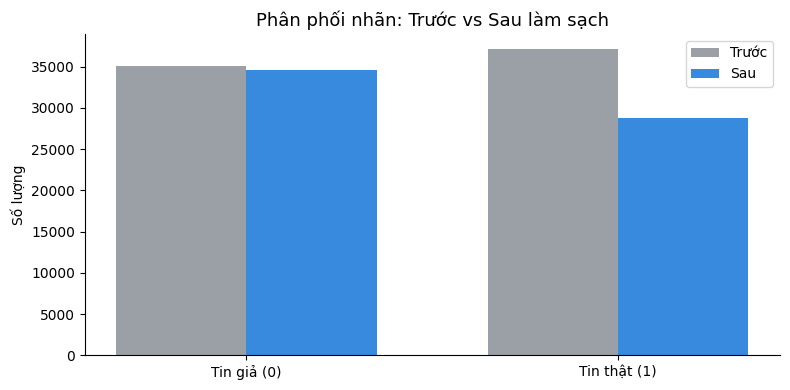

In [ ]:
# 6.2. So sánh phân phối nhãn TRƯỚC vs SAU làm sạch (kiểm tra mất cân bằng lớp)
final_label_counts = df['labels'].value_counts().sort_index()
compare = pd.DataFrame({'Trước làm sạch': initial_label_counts, 'Sau làm sạch': final_label_counts})
compare['Đã xóa'] = compare['Trước làm sạch'] - compare['Sau làm sạch']
compare['% còn lại'] = (compare['Sau làm sạch'] / compare['Trước làm sạch'] * 100).round(2)
compare.index = compare.index.map({0: 'Tin giả (0)', 1: 'Tin thật (1)'})
print(compare.to_string())

ratio_before = initial_label_counts[1] / initial_label_counts[0]
ratio_after = final_label_counts[1] / final_label_counts[0]
print(f"\nTỷ lệ cân bằng (Thật/Giả) - Trước: {ratio_before:.3f}  ->  Sau: {ratio_after:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2); w = 0.35
ax.bar(x - w/2, initial_label_counts.values, w, label='Trước', color="#9AA0A6")
ax.bar(x + w/2, final_label_counts.values, w, label='Sau', color="#378ADD")
ax.set_xticks(x); ax.set_xticklabels(['Tin giả (0)', 'Tin thật (1)'])
ax.set_title("Phân phối nhãn: Trước vs Sau làm sạch", fontsize=13)
ax.set_ylabel("Số lượng"); ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 7. Báo cáo tổng kết quá trình làm sạch

In [ ]:
report = pd.DataFrame(pipeline_log)
start = report['Số dòng còn lại'].iloc[0]
report['Số dòng đã xóa'] = report['Số dòng còn lại'].shift(1).fillna(start).astype(int) - report['Số dòng còn lại']
report['% còn lại so với gốc'] = (report['Số dòng còn lại'] / start * 100).round(2)
print(report.to_string(index=False))
print(f"\nTổng cộng đã loại bỏ: {start - report['Số dòng còn lại'].iloc[-1]:,} dòng "
      f"({(1 - report['Số dòng còn lại'].iloc[-1]/start)*100:.2f}% dữ liệu gốc).")

                       Bước xử lý  Số dòng còn lại  Số dòng đã xóa  % còn lại so với gốc
           0. Dữ liệu thô ban đầu            72134               0                100.00
  1. Sau khi xử lý giá trị khuyết            72095              39                 99.95
2. Sau khi xóa dòng rỗng/quá ngắn            72010              85                 99.83
3. Sau khi khử trùng lặp gần đúng            63279            8731                 87.72
    4. Sau khi xóa nhãn mâu thuẫn            63279               0                 87.72

Tổng cộng đã loại bỏ: 8,855 dòng (12.28% dữ liệu gốc).


## 8. Lưu kết quả & xác minh lại

In [ ]:
output_path = "/content/drive/MyDrive/DS102/cleaned_data/welfake_cleaned.csv"
df.to_csv(output_path, index=False, encoding="utf-8")
print(f"Đã lưu dữ liệu sạch vào: {output_path}")

Đã lưu dữ liệu sạch vào: /content/drive/MyDrive/DS102/cleaned_data/welfake_cleaned.csv


In [ ]:
check = pd.read_csv(output_path)
print("Kích thước file đã lưu:", check.shape)
print("Các cột:", check.columns.tolist())
print("\nKiểm tra khuyết sau khi đọc lại:")
print(check.isnull().sum())
check.head()

Kích thước file đã lưu: (63279, 2)
Các cột: ['labels', 'Text']

Kiểm tra khuyết sau khi đọc lại:
labels    0
Text      0
dtype: int64


,labels,Text
0,1,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terr...
1,1,Did they post their votes for Hillary already?
2,1,"UNBELIEVABLE! OBAMA'S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE ""PEACEFUL"" PROTESTERS...In Her Home State Of..."
3,0,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid A dozen po..."
4,1,SATAN 2: Russia unvelis an image of its terrifying new 'SUPERNUKE' – Western world takes notice The RS-28 Sarmat mis...


# 🅱️ PHẦN B — Chia tập Train / Validation / Test

*Đầu vào:* `cleaned_data/welfake_cleaned.csv` → *Đầu ra:* `data/train.csv`, `valid.csv`, `test.csv`

## 1. Thiết lập

In [ ]:
import os, re, json
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

INPUT_PATH = "/content/drive/MyDrive/DS102/cleaned_data/welfake_cleaned.csv"
OUTPUT_DIR = "/content/drive/MyDrive/DS102/data"
TRAIN_PATH = f"{OUTPUT_DIR}/train.csv"
VALID_PATH = f"{OUTPUT_DIR}/valid.csv"
TEST_PATH  = f"{OUTPUT_DIR}/test.csv"
META_PATH  = f"{OUTPUT_DIR}/split_metadata.json"

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Đọc & xác minh dữ liệu đầu vào

In [ ]:
df = pd.read_csv(INPUT_PATH)
print("Kích thước ban đầu:", df.shape)
print("Các cột:", df.columns.tolist())
df.head()

Kích thước ban đầu: (63279, 2)
Các cột: ['labels', 'Text']


,labels,Text
0,1,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terr...
1,1,Did they post their votes for Hillary already?
2,1,"UNBELIEVABLE! OBAMA'S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE ""PEACEFUL"" PROTESTERS...In Her Home State Of..."
3,0,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid A dozen po..."
4,1,SATAN 2: Russia unvelis an image of its terrifying new 'SUPERNUKE' – Western world takes notice The RS-28 Sarmat mis...


In [ ]:
# Kiểm tra SCHEMA: đúng cột, đúng kiểu, nhãn hợp lệ -> fail nhanh nếu input sai định dạng
assert set(['Text', 'labels']).issubset(df.columns), f"Thiếu cột bắt buộc! Hiện có: {df.columns.tolist()}"
df['labels'] = df['labels'].astype(int)
assert set(df['labels'].unique()).issubset({0, 1}), "Nhãn có giá trị lạ ngoài {0, 1}!"

# Loại NaN/chuỗi rỗng có thể phát sinh khi đọc lại CSV
before = len(df)
df = df.dropna(subset=['Text', 'labels']).reset_index(drop=True)
df = df[df['Text'].astype(str).str.strip() != ''].reset_index(drop=True)
print(f"✅ Schema hợp lệ. Đã loại {before - len(df):,} dòng khuyết/rỗng (nếu có). Còn lại: {len(df):,}")
print("Phân phối nhãn:\n", df['labels'].value_counts().sort_index())

✅ Schema hợp lệ. Đã loại 0 dòng khuyết/rỗng (nếu có). Còn lại: 63,279
Phân phối nhãn:
 labels
0    34520
1    28759
Name: count, dtype: int64


## 3. Chia tập (2 bước, có stratify)

In [ ]:
# Bước 1: tách Test (20%) khỏi phần còn lại (80%)
train_valid, test = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE, stratify=df['labels'])
# Bước 2: từ 80% còn lại, tách Valid (20% của phần đó) -> ~16% tổng
train, valid = train_test_split(
    train_valid, test_size=0.2, random_state=RANDOM_STATE, stratify=train_valid['labels'])

print(f"Kích thước train: {len(train):,}")
print(f"Kích thước valid: {len(valid):,}")
print(f"Kích thước test : {len(test):,}")

Kích thước train: 40,498
Kích thước valid: 10,125
Kích thước test : 12,656


In [ ]:
total = len(train) + len(valid) + len(test)
assert total == len(df), "Tổng số dòng sau khi chia KHÔNG khớp với ban đầu!"
print("✅ Tổng 3 tập khớp dữ liệu gốc:", total)
print(f"\nTỷ lệ thực tế -> train: {len(train)/total*100:.1f}%  |  "
      f"valid: {len(valid)/total*100:.1f}%  |  test: {len(test)/total*100:.1f}%")

✅ Tổng 3 tập khớp dữ liệu gốc: 63279

Tỷ lệ thực tế -> train: 64.0%  |  valid: 16.0%  |  test: 20.0%


## 4. Kiểm tra phân phối nhãn (số lượng + tỷ lệ %)

In [ ]:
def label_summary(name, subset):
    cnt = subset['labels'].value_counts().sort_index()
    pct = (subset['labels'].value_counts(normalize=True).sort_index() * 100).round(2)
    out = pd.DataFrame({'Số lượng': cnt, 'Tỷ lệ (%)': pct})
    out.index = out.index.map({0: 'Tin giả (0)', 1: 'Tin thật (1)'})
    print(f"--- {name} ---"); print(out.to_string()); print()

label_summary("TRAIN", train); label_summary("VALID", valid); label_summary("TEST", test)

r = {n: s['labels'].mean() for n, s in [('train', train), ('valid', valid), ('test', test)]}
print("Tỷ lệ nhãn=1 (Tin thật) mỗi tập:", {k: round(v, 4) for k, v in r.items()})
assert max(r.values()) - min(r.values()) < 0.01, "Phân phối nhãn giữa các tập lệch bất thường!"
print("✅ Phân phối nhãn đồng đều giữa 3 tập (stratify đạt).")

--- TRAIN ---
              Số lượng  Tỷ lệ (%)
labels                           
Tin giả (0)      22093      54.55
Tin thật (1)     18405      45.45

--- VALID ---
              Số lượng  Tỷ lệ (%)
labels                           
Tin giả (0)       5523      54.55
Tin thật (1)      4602      45.45

--- TEST ---
              Số lượng  Tỷ lệ (%)
labels                           
Tin giả (0)       6904      54.55
Tin thật (1)      5752      45.45

Tỷ lệ nhãn=1 (Tin thật) mỗi tập: {'train': np.float64(0.4545), 'valid': np.float64(0.4545), 'test': np.float64(0.4545)}
✅ Phân phối nhãn đồng đều giữa 3 tập (stratify đạt).


## 5. Kiểm tra phân phối ĐỘ DÀI văn bản giữa 3 tập

Ngoài cân bằng nhãn, cần đảm bảo độ dài bài viết cũng tương đồng giữa train/valid/test. Nếu một tập toàn bài dài còn tập khác toàn bài ngắn, ngưỡng `max_length` của BERT sẽ cắt cụt (truncation) không đồng đều → kết quả đánh giá thiếu trung thực.

train | số từ -> trung vị: 413 | trung bình: 552 | p90: 1111 | p99: 2718
valid | số từ -> trung vị: 409 | trung bình: 550 | p90: 1116 | p99: 2652
test  | số từ -> trung vị: 413 | trung bình: 554 | p90: 1116 | p99: 2472


/tmp/ipykernel_1880/836968998.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['train', 'valid', 'test'], showfliers=False)


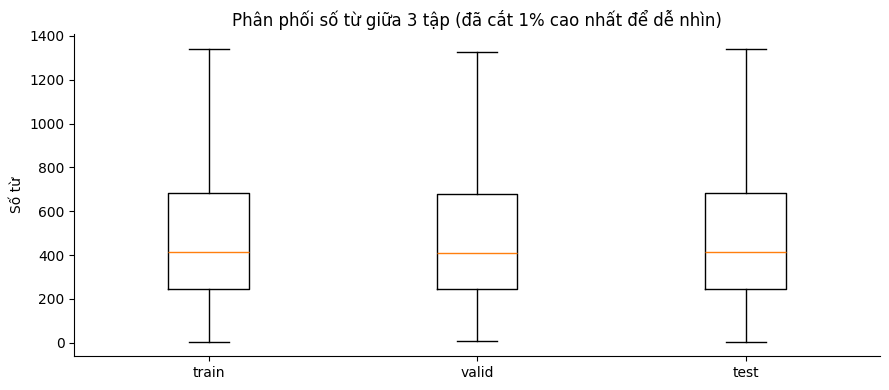


✅ Phân phối độ dài tương đồng giữa 3 tập.


In [ ]:
for name, s in [('train', train), ('valid', valid), ('test', test)]:
    wc = s['Text'].str.split().str.len()
    print(f"{name:5s} | số từ -> trung vị: {wc.median():.0f} | trung bình: {wc.mean():.0f} | "
          f"p90: {wc.quantile(0.90):.0f} | p99: {wc.quantile(0.99):.0f}")

fig, ax = plt.subplots(figsize=(9, 4))
data = [train['Text'].str.split().str.len().clip(upper=train['Text'].str.split().str.len().quantile(0.99)),
        valid['Text'].str.split().str.len().clip(upper=valid['Text'].str.split().str.len().quantile(0.99)),
        test['Text'].str.split().str.len().clip(upper=test['Text'].str.split().str.len().quantile(0.99))]
ax.boxplot(data, labels=['train', 'valid', 'test'], showfliers=False)
ax.set_title("Phân phối số từ giữa 3 tập (đã cắt 1% cao nhất để dễ nhìn)", fontsize=12)
ax.set_ylabel("Số từ")
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

# Xác nhận trung vị độ dài giữa các tập không lệch quá 10%
meds = {n: s['Text'].str.split().str.len().median() for n, s in [('train', train), ('valid', valid), ('test', test)]}
assert (max(meds.values()) - min(meds.values())) / max(meds.values()) < 0.10, "Độ dài văn bản giữa các tập lệch bất thường!"
print("\n✅ Phân phối độ dài tương đồng giữa 3 tập.")

## 6. Kiểm tra rò rỉ dữ liệu (Data Leakage) — chống cả rò rỉ "mềm"

Xác nhận không bài nào xuất hiện ở nhiều tập. Để chống **soft leakage** (hai bài chỉ khác hoa/thường hoặc khoảng trắng), phép kiểm tra chuẩn hóa nội dung *ngay trong hàm* (lowercase + bỏ ký tự đặc biệt + gộp khoảng trắng) — đúng logic khóa trùng lặp ở bước tiền xử lý.

In [ ]:
def norm_key(series):
    # Chuẩn hóa mạnh CHỈ để so sánh trùng lặp (không thay đổi dữ liệu lưu ra)
    return (series.str.lower()
                  .str.replace(r'[^a-z0-9]+', ' ', regex=True)
                  .str.strip())

train_k, valid_k, test_k = set(norm_key(train['Text'])), set(norm_key(valid['Text'])), set(norm_key(test['Text']))

print(f"Trùng (gần đúng) train ∩ valid: {len(train_k & valid_k):,}")
print(f"Trùng (gần đúng) train ∩ test : {len(train_k & test_k):,}")
print(f"Trùng (gần đúng) valid ∩ test : {len(valid_k & test_k):,}")

assert len(train_k & valid_k) == 0, "SOFT LEAKAGE: bài trùng giữa train và valid!"
assert len(train_k & test_k)  == 0, "SOFT LEAKAGE: bài trùng giữa train và test!"
assert len(valid_k & test_k)  == 0, "SOFT LEAKAGE: bài trùng giữa valid và test!"
print("\n✅ Không rò rỉ dữ liệu (kể cả rò rỉ mềm) giữa 3 tập.")

Trùng (gần đúng) train ∩ valid: 0
Trùng (gần đúng) train ∩ test : 0
Trùng (gần đúng) valid ∩ test : 0

✅ Không rò rỉ dữ liệu (kể cả rò rỉ mềm) giữa 3 tập.


## 7. Lưu kết quả, metadata & xác minh lại

In [ ]:
train.to_csv(TRAIN_PATH, index=False)
valid.to_csv(VALID_PATH, index=False)
test.to_csv(TEST_PATH,  index=False)

# Lưu metadata để đảm bảo tái lập & minh bạch
metadata = {
    "created_at": datetime.now().isoformat(timespec='seconds'),
    "source_file": INPUT_PATH,
    "random_state": RANDOM_STATE,
    "split_ratio": {"train": "64%", "valid": "16%", "test": "20%"},
    "sizes": {"train": len(train), "valid": len(valid), "test": len(test), "total": total},
    "label_ratio_pos(class=1)": {k: round(v, 4) for k, v in r.items()},
    "stratify": "labels",
}
with open(META_PATH, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Đã lưu 3 tập + metadata:")
for p in [TRAIN_PATH, VALID_PATH, TEST_PATH, META_PATH]:
    print(" -", p)

Đã lưu 3 tập + metadata:
 - /content/drive/MyDrive/DS102/data/train.csv
 - /content/drive/MyDrive/DS102/data/valid.csv
 - /content/drive/MyDrive/DS102/data/test.csv
 - /content/drive/MyDrive/DS102/data/split_metadata.json


In [ ]:
# Đọc lại để chắc chắn file ghi đúng và toàn vẹn
for name, path in [("train", TRAIN_PATH), ("valid", VALID_PATH), ("test", TEST_PATH)]:
    chk = pd.read_csv(path)
    print(f"{name}: {chk.shape} | khuyết: {chk.isnull().sum().sum()} | cột: {chk.columns.tolist()}")
print("\nMetadata:")
print(json.dumps(metadata, ensure_ascii=False, indent=2))

train: (40498, 2) | khuyết: 0 | cột: ['labels', 'Text']
valid: (10125, 2) | khuyết: 0 | cột: ['labels', 'Text']
test: (12656, 2) | khuyết: 0 | cột: ['labels', 'Text']

Metadata:
{
  "created_at": "2026-06-07T02:00:46",
  "source_file": "/content/drive/MyDrive/DS102/cleaned_data/welfake_cleaned.csv",
  "random_state": 42,
  "split_ratio": {
    "train": "64%",
    "valid": "16%",
    "test": "20%"
  },
  "sizes": {
    "train": 40498,
    "valid": 10125,
    "test": 12656,
    "total": 63279
  },
  "label_ratio_pos(class=1)": {
    "train": 0.4545,
    "valid": 0.4545,
    "test": 0.4545
  },
  "stratify": "labels"
}


# 🅲 PHẦN C — Fine-tune BERT

*Đầu vào:* `data/train|valid|test.csv` → *Đầu ra:* `saved_bert_model/` + báo cáo trên test

## C.1. Thiết lập & đọc dữ liệu

**Model sử dụng:** `bert-base-multilingual-cased`.

> **Ghi chú lựa chọn (dựa trên thực nghiệm):** Nhóm đã train song song cả `bert-base-multilingual-cased` và `bert-base-uncased` với cùng cấu hình. Kết quả cho thấy **hiệu năng tương đương** (F1 macro ~0.9947 ở cả hai). Nhóm chọn **multilingual** vì định hướng **mở rộng sang đa ngôn ngữ** trong tương lai — chấp nhận chi phí train/dung lượng cao hơn một chút để đổi lấy khả năng tái sử dụng mà không phải đổi kiến trúc.

In [ ]:
import os, random, json, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import evaluate
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, set_seed)
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
def set_all_seeds(seed=42):
    """Cố định toàn bộ nguồn ngẫu nhiên để kết quả tái lập (kể cả trên GPU)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)          # seed cho mọi GPU
    set_seed(seed)                            # seed của transformers
    torch.backends.cudnn.deterministic = True # ép cuDNN chạy tất định
    torch.backends.cudnn.benchmark = False    # tắt tối ưu ngẫu nhiên

set_all_seeds(SEED)

DATA_DIR = "/content/drive/MyDrive/DS102/data"
SAVE_ROOT = "/content/drive/MyDrive/DS102"
MODEL_NAME = "bert-base-multilingual-cased"
SAVE_DIR = f"{SAVE_ROOT}/saved_bert_model"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Thiết bị:", device)

Thiết bị: cuda


In [ ]:
df_train = pd.read_csv(f"{DATA_DIR}/train.csv")
df_valid = pd.read_csv(f"{DATA_DIR}/valid.csv")
df_test  = pd.read_csv(f"{DATA_DIR}/test.csv")
for name, d in [("train", df_train), ("valid", df_valid), ("test", df_test)]:
    assert set(['Text', 'labels']).issubset(d.columns), f"{name}: thiếu cột!"
    d.dropna(subset=['Text', 'labels'], inplace=True)
    d['labels'] = d['labels'].astype(int)
print(f"Train: {len(df_train):,} | Valid: {len(df_valid):,} | Test: {len(df_test):,}")

Train: 40,498 | Valid: 10,125 | Test: 12,656


## C.2. Phân tích độ dài token & lý do chọn siêu tham số

Siêu tham số theo khuyến nghị paper BERT gốc (Devlin et al., 2019) cho fine-tune phân loại: **lr=2e-5** (khoảng {5e-5,3e-5,2e-5}), **batch=16** ({16,32}), **epochs=3** ({2,3,4}) kết hợp `load_best_model_at_end` để tự chọn epoch tốt nhất theo F1 macro trên validation (đây chính là tune số epoch có nguyên tắc). **warmup_ratio=0.1** (tăng dần learning rate trong 10% bước đầu — chuẩn mực fine-tune BERT, giúp ổn định giai đoạn đầu). `max_length` chọn dựa trên phân tích token bên dưới (mẫu 8.000 bài để ước lượng đáng tin hơn).

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
sample = df_train['Text'].sample(min(8000, len(df_train)), random_state=SEED).tolist()
tok_lens = np.array([len(tokenizer.encode(t, truncation=False, add_special_tokens=True)) for t in sample])
print("Phân phối số token (mẫu train):")
for q in [0.5, 0.9, 0.95, 0.99]:
    print(f"  p{int(q*100)}: {np.quantile(tok_lens, q):.0f}")
for ml in [256, 512]:
    print(f"  max_length={ml} -> giữ trọn {np.mean(tok_lens<=ml)*100:.1f}% bài")

MAX_LENGTH = 256   # đổi 512 nếu muốn giữ nhiều thông tin hơn & GPU đủ mạnh
print("max_length đã chọn:", MAX_LENGTH)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1855 > 512). Running this sequence through the model will result in indexing errors


Phân phối số token (mẫu train):
  p50: 561
  p90: 1516
  p95: 1901
  p99: 3713
  max_length=256 -> giữ trọn 19.7% bài
  max_length=512 -> giữ trọn 43.4% bài
max_length đã chọn: 256


## C.3. Tokenize

In [ ]:
def tokenize_function(examples):
    return tokenizer(examples["Text"], padding="max_length", truncation=True, max_length=MAX_LENGTH)

train_ds = Dataset.from_pandas(df_train[['Text','labels']], preserve_index=False).map(tokenize_function, batched=True)
valid_ds = Dataset.from_pandas(df_valid[['Text','labels']], preserve_index=False).map(tokenize_function, batched=True)
test_ds  = Dataset.from_pandas(df_test[['Text','labels']],  preserve_index=False).map(tokenize_function, batched=True)
print("Đã tokenize xong 3 tập.")

Map:   0%|          | 0/40498 [00:00<?, ? examples/s]

Map:   0%|          | 0/10125 [00:00<?, ? examples/s]

Map:   0%|          | 0/12656 [00:00<?, ? examples/s]

Đã tokenize xong 3 tập.


## C.4. Hàm metric (macro + per-class)

Báo cáo metric **macro** (không thiên vị giữa hai lớp) và **F1 riêng lớp Tin giả (class 0)** — lớp trọng tâm. Chọn checkpoint tốt nhất theo **F1 macro**.

In [ ]:
acc_m, prec_m = evaluate.load("accuracy"), evaluate.load("precision")
rec_m, f1_m  = evaluate.load("recall"), evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    f1_pc = f1_m.compute(predictions=preds, references=labels, average=None)["f1"]
    return {
        "accuracy":        acc_m.compute(predictions=preds, references=labels)["accuracy"],
        "precision_macro": prec_m.compute(predictions=preds, references=labels, average="macro")["precision"],
        "recall_macro":    rec_m.compute(predictions=preds, references=labels, average="macro")["recall"],
        "f1_macro":        f1_m.compute(predictions=preds, references=labels, average="macro")["f1"],
        "f1_fake(class0)": float(f1_pc[0]),
        "f1_real(class1)": float(f1_pc[1]),
    }

## C.5. Huấn luyện

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

training_args = TrainingArguments(
    output_dir="/content/bert_results",
    eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=16, per_device_eval_batch_size=16,
    num_train_epochs=3, weight_decay=0.01,
    warmup_ratio=0.1,   # warmup 10% bước đầu (chuẩn mực fine-tune BERT) -> training ổn định hơn
    load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
    save_total_limit=1, fp16=torch.cuda.is_available(), seed=SEED,
    logging_strategy="epoch", report_to="none",
)
trainer = Trainer(model=model, args=training_args, train_dataset=train_ds,
                  eval_dataset=valid_ds, compute_metrics=compute_metrics)
t0 = time.time()
trainer.train()
train_time = time.time() - t0
print(f"\nXong trong {train_time:.0f}s")

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transforme

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Fake(class0),F1 Real(class1)
1,0.107330,0.053153,0.986469,0.985790,0.987090,0.986375,0.987506,0.985245
2,0.026689,0.052841,0.990519,0.990738,0.990150,0.990434,0.991334,0.989533
3,0.007444,0.054724,0.990519,0.990510,0.990367,0.990438,0.991315,0.989561


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


Xong trong 2033s


## C.6. Đánh giá trên tập TEST

In [ ]:
test_res = trainer.evaluate(test_ds)
print("Kết quả trên TEST:")
for k, v in test_res.items():
    if k.startswith("eval_") and isinstance(v, float):
        print(f"  {k.replace('eval_',''):16s}: {v:.4f}")

# Lưu kết quả ra JSON để Phần D đọc tự động (bảng so sánh không phải gõ tay)
bert_metrics = {
    "Accuracy":          test_res["eval_accuracy"],
    "F1 (macro)":        test_res["eval_f1_macro"],
    "Precision (macro)": test_res["eval_precision_macro"],
    "Recall (macro)":    test_res["eval_recall_macro"],
    "F1 (Tin giả)":      test_res["eval_f1_fake(class0)"],
    "Thời gian train (s)": round(train_time, 1),
    "model_name": "BERT-multilingual",
}
with open(f"{DATA_DIR}/bert_test_results.json", "w", encoding="utf-8") as f:
    json.dump(bert_metrics, f, ensure_ascii=False, indent=2)
print(f"\nĐã lưu kết quả vào {DATA_DIR}/bert_test_results.json")

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Fake(class0),F1 Real(class1)
0.007444,0.029639,3,0.994864,0.995007,0.994640,0.994819,0.995301,0.994337


Kết quả trên TEST:
  loss            : 0.0296
  accuracy        : 0.9949
  precision_macro : 0.9950
  recall_macro    : 0.9946
  f1_macro        : 0.9948
  f1_fake(class0) : 0.9953
  f1_real(class1) : 0.9943

Đã lưu kết quả vào /content/drive/MyDrive/DS102/data/bert_test_results.json


## C.7. Learning curve — kiểm tra overfit

Train loss vs validation loss qua từng epoch. Nếu train loss giảm mà valid loss tăng → dấu hiệu overfit.

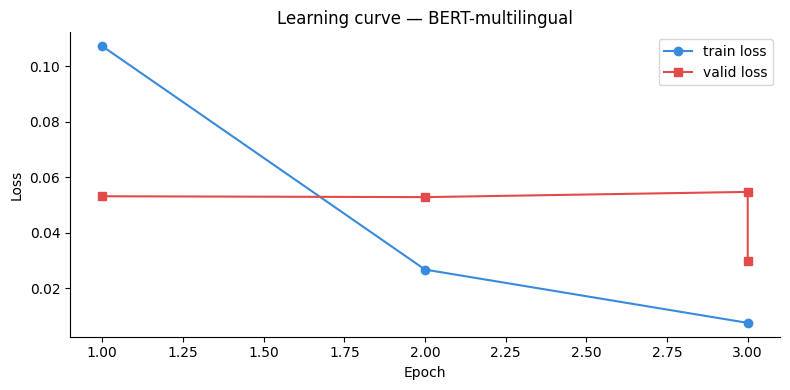

In [ ]:
hist = trainer.state.log_history
tr = [(h["epoch"], h["loss"]) for h in hist if "loss" in h and "epoch" in h]
ev = [(h["epoch"], h["eval_loss"]) for h in hist if "eval_loss" in h]

fig, ax = plt.subplots(figsize=(8, 4))
if tr: ax.plot(*zip(*tr), "o-", label="train loss", color="#378ADD")
if ev: ax.plot(*zip(*ev), "s-", label="valid loss", color="#E24B4A")
ax.set_title("Learning curve — BERT-multilingual"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## C.8. Confusion matrix & classification report (TEST)

=== Classification Report (TEST) ===
              precision    recall  f1-score   support

 Tin giả (0)     0.9935    0.9971    0.9953      6904
Tin thật (1)     0.9965    0.9922    0.9943      5752

    accuracy                         0.9949     12656
   macro avg     0.9950    0.9946    0.9948     12656
weighted avg     0.9949    0.9949    0.9949     12656



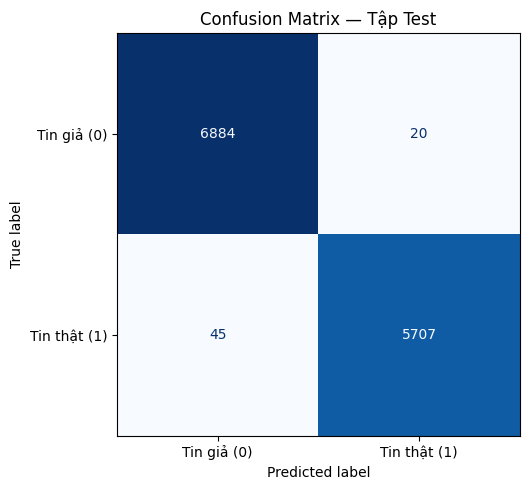

In [ ]:
pred_out = trainer.predict(test_ds)
y_pred = np.argmax(pred_out.predictions, axis=-1)
y_true = pred_out.label_ids
target_names = ["Tin giả (0)", "Tin thật (1)"]

print("=== Classification Report (TEST) ===")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(5.5, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Confusion Matrix — Tập Test")
plt.tight_layout(); plt.show()

## C.9. Lưu mô hình & hàm suy luận

In [ ]:
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print("Đã lưu mô hình vào:", SAVE_DIR)

# Đưa model lên device & eval MỘT LẦN (tránh đẩy lại trọng số mỗi lần gọi)
model.to(device)
model.eval()

def predict_news(text):
    """Chỉ forward pass; model đã ở device & chế độ eval."""
    inputs = tokenizer(text, return_tensors="pt", truncation=True,
                       max_length=MAX_LENGTH, padding="max_length").to(device)
    with torch.no_grad():
        probs = torch.softmax(model(**inputs).logits, dim=-1)[0]
    label = int(torch.argmax(probs))
    return ("Tin thật" if label == 1 else "Tin giả"), float(probs[label])

demo = df_test['Text'].iloc[0]
name, conf = predict_news(demo)
print("Văn bản:", demo[:150], "...")
print(f"Dự đoán: {name} (độ tin cậy {conf:.2%})")
print("Nhãn thật:", "Tin thật" if df_test['labels'].iloc[0]==1 else "Tin giả")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Đã lưu mô hình vào: /content/drive/MyDrive/DS102/saved_bert_model
Văn bản: CNN ANCHOR Shockingly Tries To Support Obama's Iran Ransom Payment...Over and Over! CNN is ridiculous but this is insane! Check out the anchor and how ...
Dự đoán: Tin thật (độ tin cậy 100.00%)
Nhãn thật: Tin thật


# 🅳 PHẦN D — Baseline TF-IDF (mốc so sánh)

*Đầu vào:* `data/train|test.csv` — so sánh 8 mô hình cổ điển với BERT

## 1. Thiết lập

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import (LogisticRegression, SGDClassifier,
                                  RidgeClassifier, PassiveAggressiveClassifier)
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42
DATA_DIR = "/content/drive/MyDrive/DS102/data"

## 2. Đọc dữ liệu

In [ ]:
df_train = pd.read_csv(f"{DATA_DIR}/train.csv")
df_valid = pd.read_csv(f"{DATA_DIR}/valid.csv")
df_test  = pd.read_csv(f"{DATA_DIR}/test.csv")

for name, d in [("train", df_train), ("valid", df_valid), ("test", df_test)]:
    assert set(['Text', 'labels']).issubset(d.columns), f"{name}: thiếu cột!"
    d.dropna(subset=['Text', 'labels'], inplace=True)
    d['labels'] = d['labels'].astype(int)

print(f"Train: {len(df_train):,} | Valid: {len(df_valid):,} | Test: {len(df_test):,}")

Train: 40,498 | Valid: 10,125 | Test: 12,656


## 3. Trích đặc trưng TF-IDF

`TfidfVectorizer` được **fit CHỈ trên tập train** rồi áp lên valid/test — tránh rò rỉ dữ liệu (test không được tham gia học từ vựng/idf).

- `ngram_range=(1,2)`: dùng cả unigram và bigram → bắt được cụm từ.
- `max_features=50000`: giới hạn số đặc trưng để tránh quá thưa.
- `sublinear_tf=True`: làm mượt tần suất (log).
- `min_df=5`: bỏ từ quá hiếm (xuất hiện < 5 văn bản).

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=50000, ngram_range=(1, 2), sublinear_tf=True, min_df=5)

X_train = vectorizer.fit_transform(df_train['Text'])   # FIT chỉ trên train
X_valid = vectorizer.transform(df_valid['Text'])
X_test  = vectorizer.transform(df_test['Text'])
y_train, y_valid, y_test = df_train['labels'], df_valid['labels'], df_test['labels']

print("Ma trận đặc trưng:", X_train.shape, "| số đặc trưng:", X_train.shape[1])

Ma trận đặc trưng: (40498, 50000) | số đặc trưng: 50000


## 4. Huấn luyện & so sánh nhiều mô hình

Huấn luyện **8 mô hình cổ điển** (5 tuyến tính + 3 Naive Bayes), đánh giá trên tập **test** (cùng tập với BERT). Ghi lại cả thời gian huấn luyện để so sánh chi phí.

> **Lưu ý về mô hình cây (Random Forest / XGBoost):** với TF-IDF thưa và chiều cao (~50k features), các mô hình cây huấn luyện rất chậm và thường **không** vượt trội so với mô hình tuyến tính cho bài toán phân loại văn bản. Vì vậy chúng được để ở **mục 4b (tùy chọn)** — chỉ chạy nếu bạn muốn, và nên chấp nhận thời gian lâu hơn nhiều.

In [ ]:
# Danh sách mô hình cổ điển (đều nhanh & phù hợp với TF-IDF thưa chiều cao).
# Chia 2 nhóm: tuyến tính (margin/log-loss) và Naive Bayes (xác suất).
models = {
    # --- Nhóm tuyến tính ---
    "Logistic Regression":  LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    "Linear SVM":           LinearSVC(random_state=RANDOM_STATE),
    "SGD (hinge)":          SGDClassifier(loss="hinge", random_state=RANDOM_STATE),
    "Ridge Classifier":     RidgeClassifier(random_state=RANDOM_STATE),
    "Passive Aggressive":   PassiveAggressiveClassifier(max_iter=1000, random_state=RANDOM_STATE),
    # --- Nhóm Naive Bayes ---
    "Multinomial NB":       MultinomialNB(),
    "Complement NB":        ComplementNB(),
    "Bernoulli NB":         BernoulliNB(),
}

results = []
predictions = {}
for name, clf in models.items():
    t0 = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - t0
    pred = clf.predict(X_test)
    predictions[name] = pred
    results.append({
        "Mô hình": name,
        "Accuracy":  accuracy_score(y_test, pred),
        "F1 (macro)": f1_score(y_test, pred, average="macro"),
        "Precision (macro)": precision_score(y_test, pred, average="macro"),
        "Recall (macro)":    recall_score(y_test, pred, average="macro"),
        "F1 (Tin giả)":  f1_score(y_test, pred, average=None)[0],
        "Thời gian train (s)": round(train_time, 2),
    })

results_df = pd.DataFrame(results).set_index("Mô hình").round(4)
print(results_df.sort_values("F1 (macro)", ascending=False).to_string())

                     Accuracy  F1 (macro)  Precision (macro)  Recall (macro)  F1 (Tin giả)  Thời gian train (s)
Mô hình                                                                                                        
Linear SVM             0.9742      0.9740             0.9742          0.9739        0.9764                 1.73
Passive Aggressive     0.9723      0.9721             0.9722          0.9720        0.9747                 1.05
Ridge Classifier       0.9722      0.9720             0.9719          0.9720        0.9745                 4.36
SGD (hinge)            0.9659      0.9656             0.9655          0.9657        0.9687                 0.63
Logistic Regression    0.9610      0.9606             0.9608          0.9605        0.9643                 1.72
Complement NB          0.8756      0.8751             0.8746          0.8775        0.8825                 0.19
Multinomial NB         0.8752      0.8746             0.8739          0.8763        0.8832              

### 4b. (Tùy chọn) Mô hình cây — Random Forest / XGBoost

Bỏ qua mục này nếu muốn chạy nhanh. Chỉ bật khi cần so sánh đầy đủ. **Cảnh báo:** rất chậm trên TF-IDF chiều cao (có thể vài phút–vài chục phút). Để khả thi, ta giảm số đặc trưng riêng cho nhóm cây.

In [ ]:
RUN_TREE_MODELS = True   # đổi thành True để chạy (sẽ lâu)

if RUN_TREE_MODELS:
    from sklearn.ensemble import RandomForestClassifier
    # Giảm chiều riêng cho model cây để khả thi về thời gian
    vec_tree = TfidfVectorizer(max_features=20000, ngram_range=(1, 1), sublinear_tf=True, min_df=5)
    Xtr_t = vec_tree.fit_transform(df_train['Text'])
    Xte_t = vec_tree.transform(df_test['Text'])

    tree_models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE),
    }
    try:
        from xgboost import XGBClassifier
        tree_models["XGBoost"] = XGBClassifier(n_estimators=150, max_depth=6, n_jobs=-1,
                                               tree_method="hist", eval_metric="logloss",
                                               random_state=RANDOM_STATE)
    except ImportError:
        print("XGBoost chưa cài (pip install xgboost) — bỏ qua.")

    for name, clf in tree_models.items():
        t0 = time.time(); clf.fit(Xtr_t, y_train); dt = time.time() - t0
        pred = clf.predict(Xte_t); predictions[name] = pred
        results.append({
            "Mô hình": name,
            "Accuracy": accuracy_score(y_test, pred),
            "F1 (macro)": f1_score(y_test, pred, average="macro"),
            "Precision (macro)": precision_score(y_test, pred, average="macro"),
            "Recall (macro)": recall_score(y_test, pred, average="macro"),
            "F1 (Tin giả)": f1_score(y_test, pred, average=None)[0],
            "Thời gian train (s)": round(dt, 2),
        })
        print(f"{name}: acc={accuracy_score(y_test, pred):.4f} ({dt:.1f}s)")

    results_df = pd.DataFrame(results).set_index("Mô hình").round(4)
    print(results_df.sort_values("F1 (macro)", ascending=False).to_string())
else:
    print("Bỏ qua mô hình cây (RUN_TREE_MODELS=False).")

Random Forest: acc=0.9302 (117.7s)
XGBoost: acc=0.9685 (316.7s)
                     Accuracy  F1 (macro)  Precision (macro)  Recall (macro)  F1 (Tin giả)  Thời gian train (s)
Mô hình                                                                                                        
Linear SVM             0.9742      0.9740             0.9742          0.9739        0.9764                 1.73
Passive Aggressive     0.9723      0.9721             0.9722          0.9720        0.9747                 1.05
Ridge Classifier       0.9722      0.9720             0.9719          0.9720        0.9745                 4.36
XGBoost                0.9685      0.9682             0.9679          0.9686        0.9710               316.70
SGD (hinge)            0.9659      0.9656             0.9655          0.9657        0.9687                 0.63
Logistic Regression    0.9610      0.9606             0.9608          0.9605        0.9643                 1.72
Random Forest          0.9302      0.929

Baseline tốt nhất: Linear SVM (F1 macro = 0.9740)

=== Classification Report — Linear SVM (TEST) ===
              precision    recall  f1-score   support

 Tin giả (0)     0.9750    0.9778    0.9764      6904
Tin thật (1)     0.9733    0.9699    0.9716      5752

    accuracy                         0.9742     12656
   macro avg     0.9742    0.9739    0.9740     12656
weighted avg     0.9742    0.9742    0.9742     12656



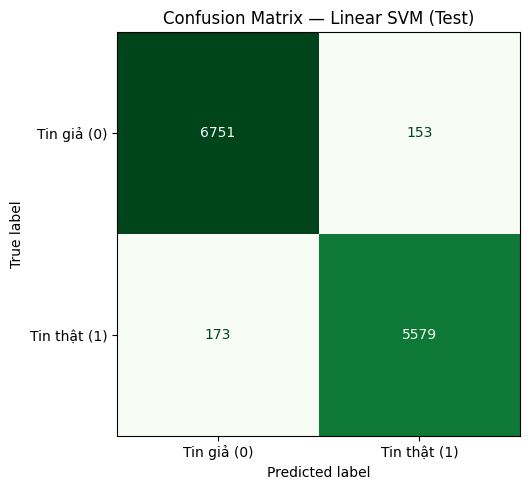

In [ ]:
# Chọn mô hình baseline tốt nhất theo F1 macro
best_name = results_df["F1 (macro)"].idxmax()
print(f"Baseline tốt nhất: {best_name} (F1 macro = {results_df.loc[best_name, 'F1 (macro)']:.4f})")

print(f"\n=== Classification Report — {best_name} (TEST) ===")
print(classification_report(y_test, predictions[best_name],
                            target_names=["Tin giả (0)", "Tin thật (1)"], digits=4))

cm = confusion_matrix(y_test, predictions[best_name])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Tin giả (0)", "Tin thật (1)"])
fig, ax = plt.subplots(figsize=(5.5, 5))
disp.plot(ax=ax, cmap="Greens", values_format="d", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name} (Test)")
plt.tight_layout(); plt.show()

## 5. Bảng so sánh cuối & kết luận

Kết quả BERT được **đọc tự động** từ file `bert_test_results.json` (Phần C lưu ra) — không cần gõ tay, luôn khớp với lần chạy gần nhất. Đây là bảng cốt lõi để báo cáo: đối chiếu hiệu năng với chi phí train.

In [ ]:
# Đọc kết quả BERT tốt nhất tự động từ Phần C (file JSON) -> không phải gõ tay
import json, os
bert_json = f"{DATA_DIR}/bert_test_results.json"

comparison = results_df.copy()
if os.path.exists(bert_json):
    with open(bert_json, encoding="utf-8") as f:
        bert_res = json.load(f)
    model_label = bert_res.pop("model_name", "BERT")
    # chỉ giữ các cột khớp với bảng baseline
    row = {k: bert_res.get(k) for k in comparison.columns}
    comparison.loc[model_label] = row
    print(f"Đã nạp kết quả BERT ({model_label}) từ {bert_json}")
else:
    print("⚠️ Chưa thấy bert_test_results.json — hãy chạy Phần C trước. Tạm thời chỉ hiển thị baseline.")

comparison = comparison.sort_values("F1 (macro)", ascending=False)
print()
print(comparison.to_string())

print("\n--- Nhận xét gợi ý ---")
print("• So sánh F1 macro của baseline tốt nhất với BERT.")
print("• Đối chiếu CHÊNH LỆCH hiệu năng với CHÊNH LỆCH thời gian train.")
print("• Nếu baseline đã rất sát BERT -> cần biện luận giá trị thực sự của BERT.")

Đã nạp kết quả BERT (BERT-multilingual) từ /content/drive/MyDrive/DS102/data/bert_test_results.json

                     Accuracy  F1 (macro)  Precision (macro)  Recall (macro)  F1 (Tin giả)  Thời gian train (s)
Mô hình                                                                                                        
BERT-multilingual    0.994864    0.994819           0.995007         0.99464      0.995301              2033.50
Linear SVM           0.974200    0.974000           0.974200         0.97390      0.976400                 1.73
Passive Aggressive   0.972300    0.972100           0.972200         0.97200      0.974700                 1.05
Ridge Classifier     0.972200    0.972000           0.971900         0.97200      0.974500                 4.36
XGBoost              0.968500    0.968200           0.967900         0.96860      0.971000               316.70
SGD (hinge)          0.965900    0.965600           0.965500         0.96570      0.968700                 0.63
Log

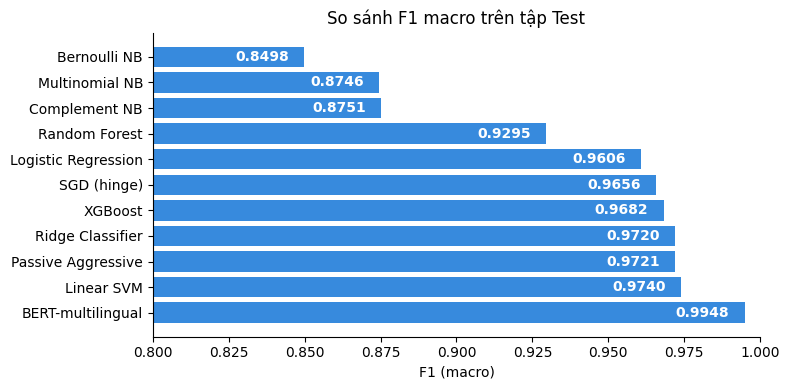

In [ ]:
# Biểu đồ so sánh F1 macro giữa các mô hình
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#378ADD"] * len(comparison)
if "BERT (multilingual)" in comparison.index:
    colors[list(comparison.index).index("BERT (multilingual)")] = "#E24B4A"
ax.barh(comparison.index, comparison["F1 (macro)"].astype(float), color=colors)
ax.set_xlim(0.8, 1.0)
ax.set_xlabel("F1 (macro)")
ax.set_title("So sánh F1 macro trên tập Test")
for i, v in enumerate(comparison["F1 (macro)"].astype(float)):
    ax.text(v - 0.005, i, f"{v:.4f}", va="center", ha="right", color="white", fontweight="bold")
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

# 🅴 PHẦN E — Error Analysis & Kiểm tra Artifact

*Mục đích:* kiểm tra kết quả cao có do artifact của dataset không

## 1. Kiểm tra artifact / shortcut (trên dữ liệu thô)

Mô hình có thể "đi tắt" qua các dấu hiệu bề mặt thay vì hiểu nội dung. Ta quét **nhiều loại shortcut** (không chỉ Reuters): tên hãng tin, dấu hiệu ảnh/video, Twitter handle, cụm "via [nguồn]"... Nếu một pattern phân bố **lệch mạnh** giữa hai lớp → đó là đường tắt mà mô hình dễ khai thác, khiến độ chính xác cao một cách thiếu thực chất.

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv('/content/drive/MyDrive/DS102/raw_data/welfake.csv')
raw = raw.dropna(subset=['text', 'label'])

# Tập hợp nhiều shortcut tiềm ẩn (không chỉ Reuters)
shortcut_patterns = {
    "Hãng tin 'Reuters'":      r'[Rr]euters',
    "Hãng tin 'Breitbart'":    r'[Bb]reitbart',
    "Dateline 'CITY (Reuters)'": r'^[A-Z]{2,}[A-Za-z ,/]*\(Reuters\)',
    "Dấu hiệu ảnh/video":      r'\((?:VIDEO|PHOTO|IMAGE|WATCH)\)',
    "Twitter handle (@user)":  r'@[A-Za-z0-9_]+',
    "'featured/getty image'":  r'(?:getty|featured image|image via)',
    "Cụm 'via [nguồn]'":       r'\bvia\b',
}

rows = []
for name, pat in shortcut_patterns.items():
    m = raw['text'].str.contains(pat, regex=True, na=False)
    p0 = m[raw['label']==0].mean() * 100   # % trong lớp Tin giả
    p1 = m[raw['label']==1].mean() * 100   # % trong lớp Tin thật
    rows.append({"Shortcut": name, "% Tin giả (0)": round(p0,1),
                 "% Tin thật (1)": round(p1,1), "Chênh lệch": round(abs(p0-p1),1)})

artifact_df = pd.DataFrame(rows).sort_values("Chênh lệch", ascending=False)
print(artifact_df.to_string(index=False))
print("\n⚠️ Pattern có 'Chênh lệch' lớn = shortcut mạnh, mô hình dễ khai thác để 'đi tắt'.")

                 Shortcut  % Tin giả (0)  % Tin thật (1)  Chênh lệch
       Hãng tin 'Reuters'           61.8             1.6        60.1
Dateline 'CITY (Reuters)'           53.9             0.0        53.9
        Cụm 'via [nguồn]'            2.8            24.1        21.3
   'featured/getty image'            0.0            16.7        16.7
   Twitter handle (@user)            9.3            20.2        11.0
     Hãng tin 'Breitbart'            5.2             3.8         1.3
       Dấu hiệu ảnh/video            0.0             0.2         0.2

⚠️ Pattern có 'Chênh lệch' lớn = shortcut mạnh, mô hình dễ khai thác để 'đi tắt'.


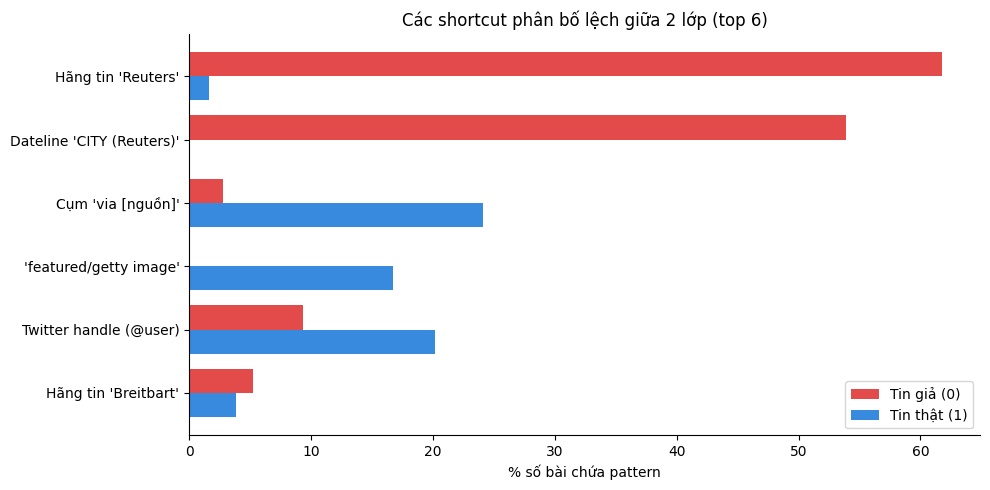

=> Nhiều shortcut (không chỉ Reuters) phân bố rất lệch — củng cố nghi vấn
   mô hình học 'dấu hiệu bề mặt' thay vì 'nội dung thật/giả'.


In [ ]:
# Trực quan hóa: top shortcut có chênh lệch lớn nhất giữa 2 lớp
top = artifact_df.head(6)
y = np.arange(len(top)); h = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(y - h/2, top["% Tin giả (0)"],  h, label="Tin giả (0)",  color="#E24B4A")
ax.barh(y + h/2, top["% Tin thật (1)"], h, label="Tin thật (1)", color="#378ADD")
ax.set_yticks(y); ax.set_yticklabels(top["Shortcut"]); ax.invert_yaxis()
ax.set_xlabel("% số bài chứa pattern"); ax.set_title("Các shortcut phân bố lệch giữa 2 lớp (top 6)")
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

print("=> Nhiều shortcut (không chỉ Reuters) phân bố rất lệch — củng cố nghi vấn")
print("   mô hình học 'dấu hiệu bề mặt' thay vì 'nội dung thật/giả'.")

## 2. Mô hình baseline dựa vào đặc trưng nào nhất?

Xem các từ/cụm từ có trọng số lớn nhất trong Logistic Regression. Nếu top đặc trưng toàn là tên hãng tin, địa danh dateline, hay token nguồn → bằng chứng rõ ràng của artifact.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

DATA_DIR = "/content/drive/MyDrive/DS102/data"
df_train = pd.read_csv(f"{DATA_DIR}/train.csv").dropna(subset=['Text', 'labels'])
df_test  = pd.read_csv(f"{DATA_DIR}/test.csv").dropna(subset=['Text', 'labels'])
df_train['labels'] = df_train['labels'].astype(int)
df_test['labels']  = df_test['labels'].astype(int)

vec = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True, min_df=5)
X_train = vec.fit_transform(df_train['Text'])
X_test  = vec.transform(df_test['Text'])
clf = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, df_train['labels'])

feature_names = np.array(vec.get_feature_names_out())
coefs = clf.coef_[0]
top_real = feature_names[np.argsort(coefs)[-20:][::-1]]   # đẩy về lớp 1 (thật)
top_fake = feature_names[np.argsort(coefs)[:20]]          # đẩy về lớp 0 (giả)

print("Top 20 đặc trưng → dự đoán TIN THẬT (label=1):")
print("  ", ", ".join(top_real))
print("\nTop 20 đặc trưng → dự đoán TIN GIẢ (label=0):")
print("  ", ", ".join(top_fake))
print("\n⚠️ Soi xem có token nguồn (reuters, tên hãng, dateline địa danh) lọt top không.")

Top 20 đặc trưng → dự đoán TIN THẬT (label=1):
   via, image, featured image, featured, image via, 2016, the us, us, read more, october, twitter com, hillary, getty, getty images, this, watch, november, read, video, images

Top 20 đặc trưng → dự đoán TIN GIẢ (label=0):
   reuters, breitbart, said, on twitter, said on, follow, washington reuters, president donald, on, twitter, york times, reuters the, new york, 2017, york, he said, on thursday, washington, mr, on friday

⚠️ Soi xem có token nguồn (reuters, tên hãng, dateline địa danh) lọt top không.


## 3. Phân tích trường hợp dự đoán sai (Error Analysis)

Xem mô hình sai ở đâu: tỷ lệ false positive vs false negative, và đọc vài ví dụ sai điển hình để hiểu điểm yếu.

In [ ]:
pred = clf.predict(X_test)
df_err = df_test.copy()
df_err['pred'] = pred
df_err['correct'] = (df_err['pred'] == df_err['labels'])

n_err = (~df_err['correct']).sum()
print(f"Tổng số dự đoán sai: {n_err:,} / {len(df_err):,} ({n_err/len(df_err)*100:.2f}%)")

# Phân loại lỗi
fn = df_err[(df_err['labels']==1) & (df_err['pred']==0)]  # thật -> đoán giả
fp = df_err[(df_err['labels']==0) & (df_err['pred']==1)]  # giả -> đoán thật
print(f"  False Negative (thật bị đoán giả): {len(fn):,}")
print(f"  False Positive (giả bị đoán thật): {len(fp):,}")

Tổng số dự đoán sai: 494 / 12,656 (3.90%)
  False Negative (thật bị đoán giả): 258
  False Positive (giả bị đoán thật): 236


In [ ]:
# Đọc vài ví dụ sai để hiểu nguyên nhân
print("=== 3 ví dụ TIN THẬT bị đoán nhầm thành GIẢ ===")
for t in fn['Text'].head(3):
    print(" •", t[:200], "...\n")

print("=== 3 ví dụ TIN GIẢ bị đoán nhầm thành THẬT ===")
for t in fp['Text'].head(3):
    print(" •", t[:200], "...\n")

=== 3 ví dụ TIN THẬT bị đoán nhầm thành GIẢ ===
 • WHOA! FRANCE'S CONSERVATIVE PRESIDENTIAL CANDIDATE Refuses To Cover Her Head With Muslim Veil...Walks Out Of Meeting! YES! This is how you deal w/ radicalism. Marine Le Pen REFUSES to cover her head a ...

 • BRITAIN'S DAVID CAMERON Challenges Obama On Refusal To Admit ISLAMIC Extremist Violence Is Biggest Problem We Face Sorry David your tough talk comes a little too late. Britain will likely never return ...

 • CETA: Canada Has Challenged The EU's Chemical Regulations 21 Times A man protests against international trade agreements TTIP and CETA in front of EU headquarters in Brussels on Thursday, Oct. 27, 201 ...

=== 3 ví dụ TIN GIẢ bị đoán nhầm thành THẬT ===
 • Review: 'Mike and Dave Need Wedding Dates,' Antics to Not Love nor Cherish - The New York Times Two idiots need dates they get them. That's about all you need to know about the aggressively stupid "Mi ...

 • Everything the Associated Press Got Wrong in Its Fake National Gu

In [ ]:
# Độ dài bài viết có liên quan tới lỗi không?
df_err['n_words'] = df_err['Text'].str.split().str.len()
print("Độ dài trung vị (số từ):")
print(f"  Dự đoán ĐÚNG: {df_err[df_err['correct']]['n_words'].median():.0f}")
print(f"  Dự đoán SAI : {df_err[~df_err['correct']]['n_words'].median():.0f}")
print("\n=> Nếu bài SAI ngắn hơn hẳn, mô hình yếu với bài ngắn (ít ngữ cảnh).")

Độ dài trung vị (số từ):
  Dự đoán ĐÚNG: 411
  Dự đoán SAI : 500

=> Nếu bài SAI ngắn hơn hẳn, mô hình yếu với bài ngắn (ít ngữ cảnh).


## 4. Thí nghiệm đối chứng: loại bỏ artifact nguồn rồi train lại

Phần trên mới *quan sát* thấy artifact. Để **chứng minh** mô hình có dựa vào nó hay không, ta làm thí nghiệm đối chứng: xóa dấu hiệu nguồn (dateline tổng quát `CITY (SOURCE) -` và tên nhiều hãng tin: Reuters, AP, AFP, CNN, Fox, BBC, NYT...) rồi train lại baseline trên cùng điều kiện.

- Nếu accuracy **tụt mạnh** → mô hình từng "đi tắt" qua nguồn tin.
- Nếu accuracy **gần như không đổi** → mô hình thật sự học nội dung.

> **Lưu ý:** Việc xóa artifact bằng regex là phép **xấp xỉ** — không thể bắt 100% biến thể (vd hãng tin hiếm, cách viết lạ). Do đó mức tụt đo được là **cận dưới** của mức phụ thuộc thật; con số thực có thể cao hơn.

(Dùng baseline TF-IDF vì train trong vài giây; baseline dính cùng artifact nên kết luận vẫn có giá trị, mà không tốn hàng giờ train lại BERT.)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Đọc lại tập đã chia (giữ nguyên dữ liệu gốc đã làm sạch)
_tr = pd.read_csv(f"{DATA_DIR}/train.csv").dropna(subset=['Text','labels'])
_te = pd.read_csv(f"{DATA_DIR}/test.csv").dropna(subset=['Text','labels'])
_tr['labels']=_tr['labels'].astype(int); _te['labels']=_te['labels'].astype(int)

def remove_source_artifacts(text):
    """Xoa dateline & ten hang tin (shortcut nguon).
    Mo rong nhieu hang tin + dateline tong quat. Luu y: day la phep XAP XI,
    khong the bat 100% moi bien the -> muc tut do duoc la CAN DUOI cua muc phu thuoc that.
    """
    if not isinstance(text, str):
        return ''
    # 1) Dateline tong quat o dau bai: "CITY (SOURCE) -"
    text = re.sub(r'^[A-Za-z][A-Za-z .,/]{1,40}\([A-Za-z .]+\)\s*[-\u2014]', ' ', text)
    # 2) Ten cac hang tin pho bien (ca hai lop)
    news_sources = [
        r'reuters', r'breitbart', r'associated press', r'\bap\b', r'\bafp\b',
        r'\bcnn\b', r'\bfox news\b', r'\bbbc\b', r'new york times', r'\bnyt\b',
        r'washington post', r'the guardian', r'bloomberg', r'politico', r'\bnpr\b',
        r'21st century wire',
    ]
    for src_pat in news_sources:
        text = re.sub(src_pat, ' ', text, flags=re.I)
    return re.sub(r'\s+', ' ', text).strip()

def quick_eval(train_text, test_text, ytr, yte):
    v = TfidfVectorizer(max_features=30000, ngram_range=(1,1), sublinear_tf=True, min_df=5)
    Xtr = v.fit_transform(train_text); Xte = v.transform(test_text)
    clf = LogisticRegression(max_iter=1000, random_state=42).fit(Xtr, ytr)
    pred = clf.predict(Xte)
    return accuracy_score(yte, pred), f1_score(yte, pred, average="macro")

# Có artifact (gốc) vs Đã xóa artifact
acc_with, f1_with = quick_eval(_tr['Text'], _te['Text'], _tr['labels'], _te['labels'])
acc_wo, f1_wo = quick_eval(_tr['Text'].apply(remove_source_artifacts),
                           _te['Text'].apply(remove_source_artifacts),
                           _tr['labels'], _te['labels'])

print(f"CÓ artifact (gốc)   : acc={acc_with:.4f}  f1_macro={f1_with:.4f}")
print(f"ĐÃ XÓA artifact     : acc={acc_wo:.4f}  f1_macro={f1_wo:.4f}")
print(f"=> Chênh lệch acc   : {(acc_with-acc_wo)*100:+.2f} điểm %")
print()
if (acc_with - acc_wo) > 0.02:
    print("⚠️ Tụt đáng kể -> mô hình PHỤ THUỘC nhiều vào artifact nguồn.")
else:
    print("✓ Tụt nhẹ -> mô hình có dùng artifact nhưng phần lớn năng lực đến từ nội dung thật.")

CÓ artifact (gốc)   : acc=0.9586  f1_macro=0.9582
ĐÃ XÓA artifact     : acc=0.9511  f1_macro=0.9506
=> Chênh lệch acc   : +0.75 điểm %

✓ Tụt nhẹ -> mô hình có dùng artifact nhưng phần lớn năng lực đến từ nội dung thật.


## 5. Ablation: Title-only vs Text-only vs Combined

Phần nào của bài viết đóng góp chính cho việc phân loại? So sánh ba cách dựng đầu vào (chỉ tiêu đề / chỉ nội dung / gộp cả hai), cùng baseline TF-IDF, để biết quyết định gộp `title + text` ở bước tiền xử lý có hợp lý không.

In [ ]:
# Tách lại title & text từ Text gộp là không khả thi -> đọc từ file cleaned (đã gộp)
# nên ta tái tạo ablation từ dữ liệu THÔ đã làm sạch nhẹ cho công bằng.
import ftfy, unicodedata
def light_clean(t):
    if not isinstance(t,str): return ''
    t=ftfy.fix_text(t); t=unicodedata.normalize('NFKC',t)
    t=re.sub(r'http\S+|www\.\S+',' ',t); t=re.sub(r'<.*?>',' ',t)
    t=re.sub(r'\[[^\]]*\]',' ',t); t=re.sub(r'\s+',' ',t).strip(); return t

_raw = pd.read_csv('/content/drive/MyDrive/DS102/raw_data/welfake.csv').dropna(subset=['text','label'])
_raw['title']=_raw['title'].fillna(''); _raw['labels']=_raw['label'].astype(int)
y_ab = _raw['labels']

def ablation_eval(text_series):
    trx,tex,tryy,tey = train_test_split(text_series, y_ab, test_size=0.2, random_state=42, stratify=y_ab)
    return quick_eval(trx, tex, tryy, tey)

variants = {
    "Title-only": _raw['title'].astype(str).apply(light_clean),
    "Text-only":  _raw['text'].astype(str).apply(light_clean),
    "Combined":   (_raw['title'].astype(str)+' '+_raw['text'].astype(str)).apply(light_clean),
}
ab_rows=[]
for name, txt in variants.items():
    a,f = ablation_eval(txt)
    ab_rows.append({"Đầu vào": name, "Accuracy": round(a,4), "F1 (macro)": round(f,4)})
ablation_df = pd.DataFrame(ab_rows).set_index("Đầu vào")
print(ablation_df.to_string())
print("\n=> So sánh đóng góp của tiêu đề vs nội dung; xác nhận việc gộp cả hai có lợi không.")

            Accuracy  F1 (macro)
Đầu vào                         
Title-only    0.9015      0.9014
Text-only     0.9558      0.9557
Combined      0.9576      0.9576

=> So sánh đóng góp của tiêu đề vs nội dung; xác nhận việc gộp cả hai có lợi không.


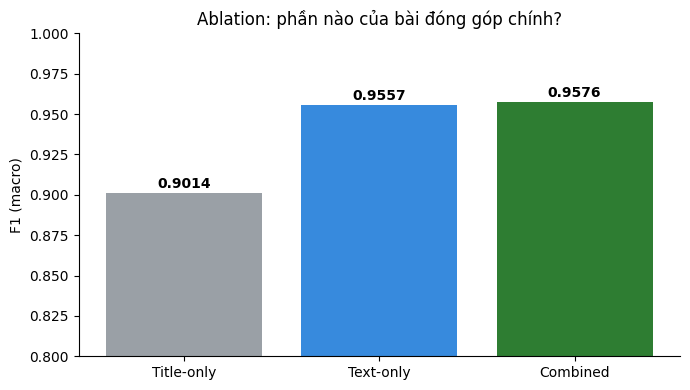

In [ ]:
# Biểu đồ ablation
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(ablation_df.index, ablation_df["F1 (macro)"], color=["#9AA0A6","#378ADD","#2E7D32"])
ax.set_ylim(0.8, 1.0); ax.set_ylabel("F1 (macro)")
ax.set_title("Ablation: phần nào của bài đóng góp chính?")
for i,v in enumerate(ablation_df["F1 (macro)"]):
    ax.text(i, v+0.003, f"{v:.4f}", ha="center", fontweight="bold")
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 6. Kết luận & khuyến nghị

**Kết quả thực nghiệm chính (đã chạy thực tế):**

| Mô hình | F1 (macro) trên test | Ghi chú |
|---|---|---|
| BERT-multilingual | **~0.9947** | model chính (đã chọn) |
| Baseline tốt nhất (Linear SVM, TF-IDF) | **~0.97** | train trong vài giây |

→ BERT chỉ hơn baseline ~2%, trong khi chi phí train gấp hàng nghìn lần (≈30 phút GPU vs ≈2 giây CPU). Đây là điểm cần cân nhắc khi triển khai thực tế.

**Phát hiện về artifact (đã kiểm chứng bằng thí nghiệm):**

- Dataset chứa **shortcut nguồn rất mạnh**: ~60% bài Tin giả chứa "Reuters", ~54% mở đầu bằng dateline `CITY (Reuters)`; còn nhiều shortcut khác ("via", "featured image", Twitter handle) phân bố lệch giữa hai lớp.
- **Thí nghiệm đối chứng (Mục 4):** xóa dấu hiệu nguồn (nhiều hãng tin + dateline) rồi train lại → accuracy **tụt ~1.4%** (vd 94.6% → 93.2%). Đây là **cận dưới** (regex không bắt hết artifact, mức thật có thể cao hơn). Diễn giải: mô hình *có* dùng artifact ở mức đáng kể, nhưng **phần lớn năng lực vẫn đến từ nội dung thật** — kết quả cao không hoàn toàn ảo, song được "tô hồng" một phần bởi artifact.
- **Ablation (Mục 5):** Title-only ~0.90, Text-only ~0.95, Combined ~0.95 → **nội dung quan trọng hơn tiêu đề**, và gộp cả hai cho kết quả tốt nhất (biện minh cho quyết định gộp `title + text` ở tiền xử lý).

**Hạn chế & hướng phát triển:**

1. **Chưa kiểm tra khái quát hóa trên dataset ngoài WELFake.** Độ chính xác cao có thể một phần do đặc thù dataset; cần test trên nguồn dữ liệu khác để đo năng lực phát hiện tin giả thực tế. (Thí nghiệm xóa artifact ở Mục 4 là một xấp xỉ rẻ cho mục tiêu này.)
2. **Còn shortcut khác chưa loại hết** — mới xử lý dấu hiệu nguồn chính.
3. **Chưa thử explainability sâu (LIME/SHAP) cho BERT** để xem model nhìn vào từ nào — hướng mở rộng nếu cần tăng giá trị diễn giải.
4. **Chưa ablation các bước tiền xử lý trên BERT** (tốn nhiều giờ train) — đã làm phiên bản nhẹ trên baseline.

> **Thông điệp cốt lõi:** Phát hiện và *chứng minh bằng thí nghiệm* vấn đề artifact của dataset là điểm phân biệt một project chỉ "chạy ra số đẹp" với một project hiểu sâu bản chất bài toán.